1. Import Libraries and Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# load and combine historical datasets
files = ['dataset_prnN9_2013.csv.xlsx', 'dataset_prnN9_2018.csv.xlsx', 'dataset_prnN9_2023.csv.xlsx']
df_list = [pd.read_excel(f) for f in files]
df_all = pd.concat(df_list, ignore_index = True)

print("Data loaded successfully.")
print(df_all.head())

Data loaded successfully.
  Constituency_Name Incumbent_Party  ...  Constituency_ID  Year
0           Chennah             MCA  ...              N01  2013
1           Pertang            UMNO  ...              N02  2013
2        Sungai Lui            UMNO  ...              N03  2013
3           Klawang            UMNO  ...              N04  2013
4           Serting            UMNO  ...              N05  2013

[5 rows x 8 columns]


2. Data Preprocessing

In [33]:
# initialize encoder for the target variable
le = LabelEncoder()
df_all['Winner_Party_Encoded'] = le.fit_transform(df['Winner_Party'])

# define the list of columns to remove for training
cols_to_drop = [
    'Constituency_Name',
    'Winner_Party',
    'Incumbent_Party',
    'Constituency_ID',
    'Winner_Party_Encoded'
]

# create X (features) by dropping the non-predictive/target columns
X = df_all.drop(columns=cols_to_drop)

# create y (target)
y = df_all['Winner_Party_Encoded']

print("Data preprocessed successfully.")


Data preprocessed successfully.


3. Model Training and Evaluation

In [34]:
# initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

# train and collect scores
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = score
    print(f"{name} Accuracy: {score:.4f}")

Random Forest Accuracy: 0.5833
Logistic Regression Accuracy: 0.5833
Support Vector Machine Accuracy: 0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4. Visualization

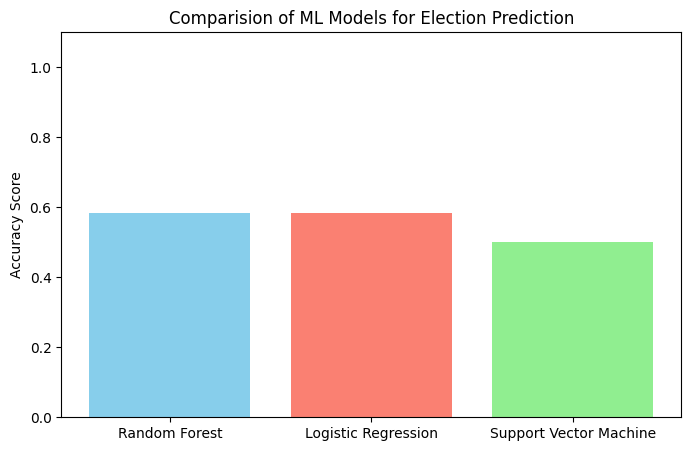

In [35]:
plt.figure(figsize = (8, 5))
plt.bar(results.keys(), results.values(), color = ['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Accuracy Score')
plt.title('Comparision of ML Models for Election Prediction')
plt.ylim(0, 1.1)
plt.show()

5. Prediction

In [37]:
# calculate historical average features per seat
avg_seat_profiles = df_all.groupby('Constituency_ID')[['Votes_Received', 'Total_Votes', 'Vote_Margin']].mean().reset_index()

# prepare 2026 input
X_2026 = avg_seat_profiles.copy()
X_2026['Year'] = 2026

# preidct using the model trained on combined data
predictions = best_model.predict(X_2026[['Votes_Received', 'Total_Votes', 'Vote_Margin', 'Year']])
predicted_parties = le.inverse_transform(predictions)

# merge results with seat names
constituencies = df_all[['Constituency_Name', 'Constituency_ID']].drop_duplicates()
results_2026 = pd.merge(constituencies,
                        pd.DataFrame({'Constituency_ID': X_2026['Constituency_ID'],
                                      'Predicted_Winner_Party': predicted_parties}),
                        on = 'Constituency_ID')

# display the full 36-seat prediction table
print(results_2026.sort_values('Constituency_ID').to_string(index = False))


Constituency_Name Constituency_ID Predicted_Winner_Party
          Chennah             N01                   UMNO
          Pertang             N02                   UMNO
       Sungai Lui             N03                   UMNO
          Klawang             N04                   UMNO
          Serting             N05                   UMNO
           Palong             N06                   UMNO
     Jeram Padang             N07                   UMNO
            Bahau             N08                   UMNO
         Lenggeng             N09                   UMNO
            Nilai             N10                    DAP
            Lobak             N11                    DAP
          Temiang             N12                   UMNO
          Sikamat             N13                   UMNO
         Ampangan             N14                   UMNO
          Juasseh             N15                   UMNO
     Seri Menanti             N16                   UMNO
         Senaling             N